In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add src to path so we can import your custom modules
sys.path.append('../src')
import config
from preprocessing import full_preprocessing_and_save
from data_loader import get_pytorch_loaders

# Visualization Settings
%matplotlib inline
sns.set(style="whitegrid")

In [3]:
# Load the raw data to explore it before processing
df_raw = pd.read_csv('../' + config.DATA_PATH)

print(f"📊 Dataset Shape: {df_raw.shape}")
print("\n📝 First 5 Rows:")
display(df_raw.head())

print("\nℹ️ Dataset Information:")
df_raw.info()

📊 Dataset Shape: (5000, 16)

📝 First 5 Rows:


,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0



ℹ️ Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   bmi                5000 non-null   float64
 3   exercise_level     5000 non-null   int64  
 4   smoking            5000 non-null   int64  
 5   alcohol            5000 non-null   int64  
 6   blood_pressure     5000 non-null   int64  
 7   cholesterol        5000 non-null   int64  
 8   glucose            5000 non-null   int64  
 9   fatigue            5000 non-null   int64  
 10  chest_pain         5000 non-null   int64  
 11  dizziness          5000 non-null   int64  
 12  heart_disease      5000 non-null   int64  
 13  diabetes           5000 non-null   int64  
 14  stroke             5000 non-null   int64  
 15  health_risk_score  5000 non-null   float64
dtyp

In [9]:
import pandas as pd
import config

# LOAD THE DATA FIRST
df = pd.read_csv('../' + config.DATA_PATH) 

# Now the code below will work
missing_values = df.isnull().sum()
print(missing_values)

age                  0
gender               0
bmi                  0
exercise_level       0
smoking              0
alcohol              0
blood_pressure       0
cholesterol          0
glucose              0
fatigue              0
chest_pain           0
dizziness            0
heart_disease        0
diabetes             0
stroke               0
health_risk_score    0
dtype: int64


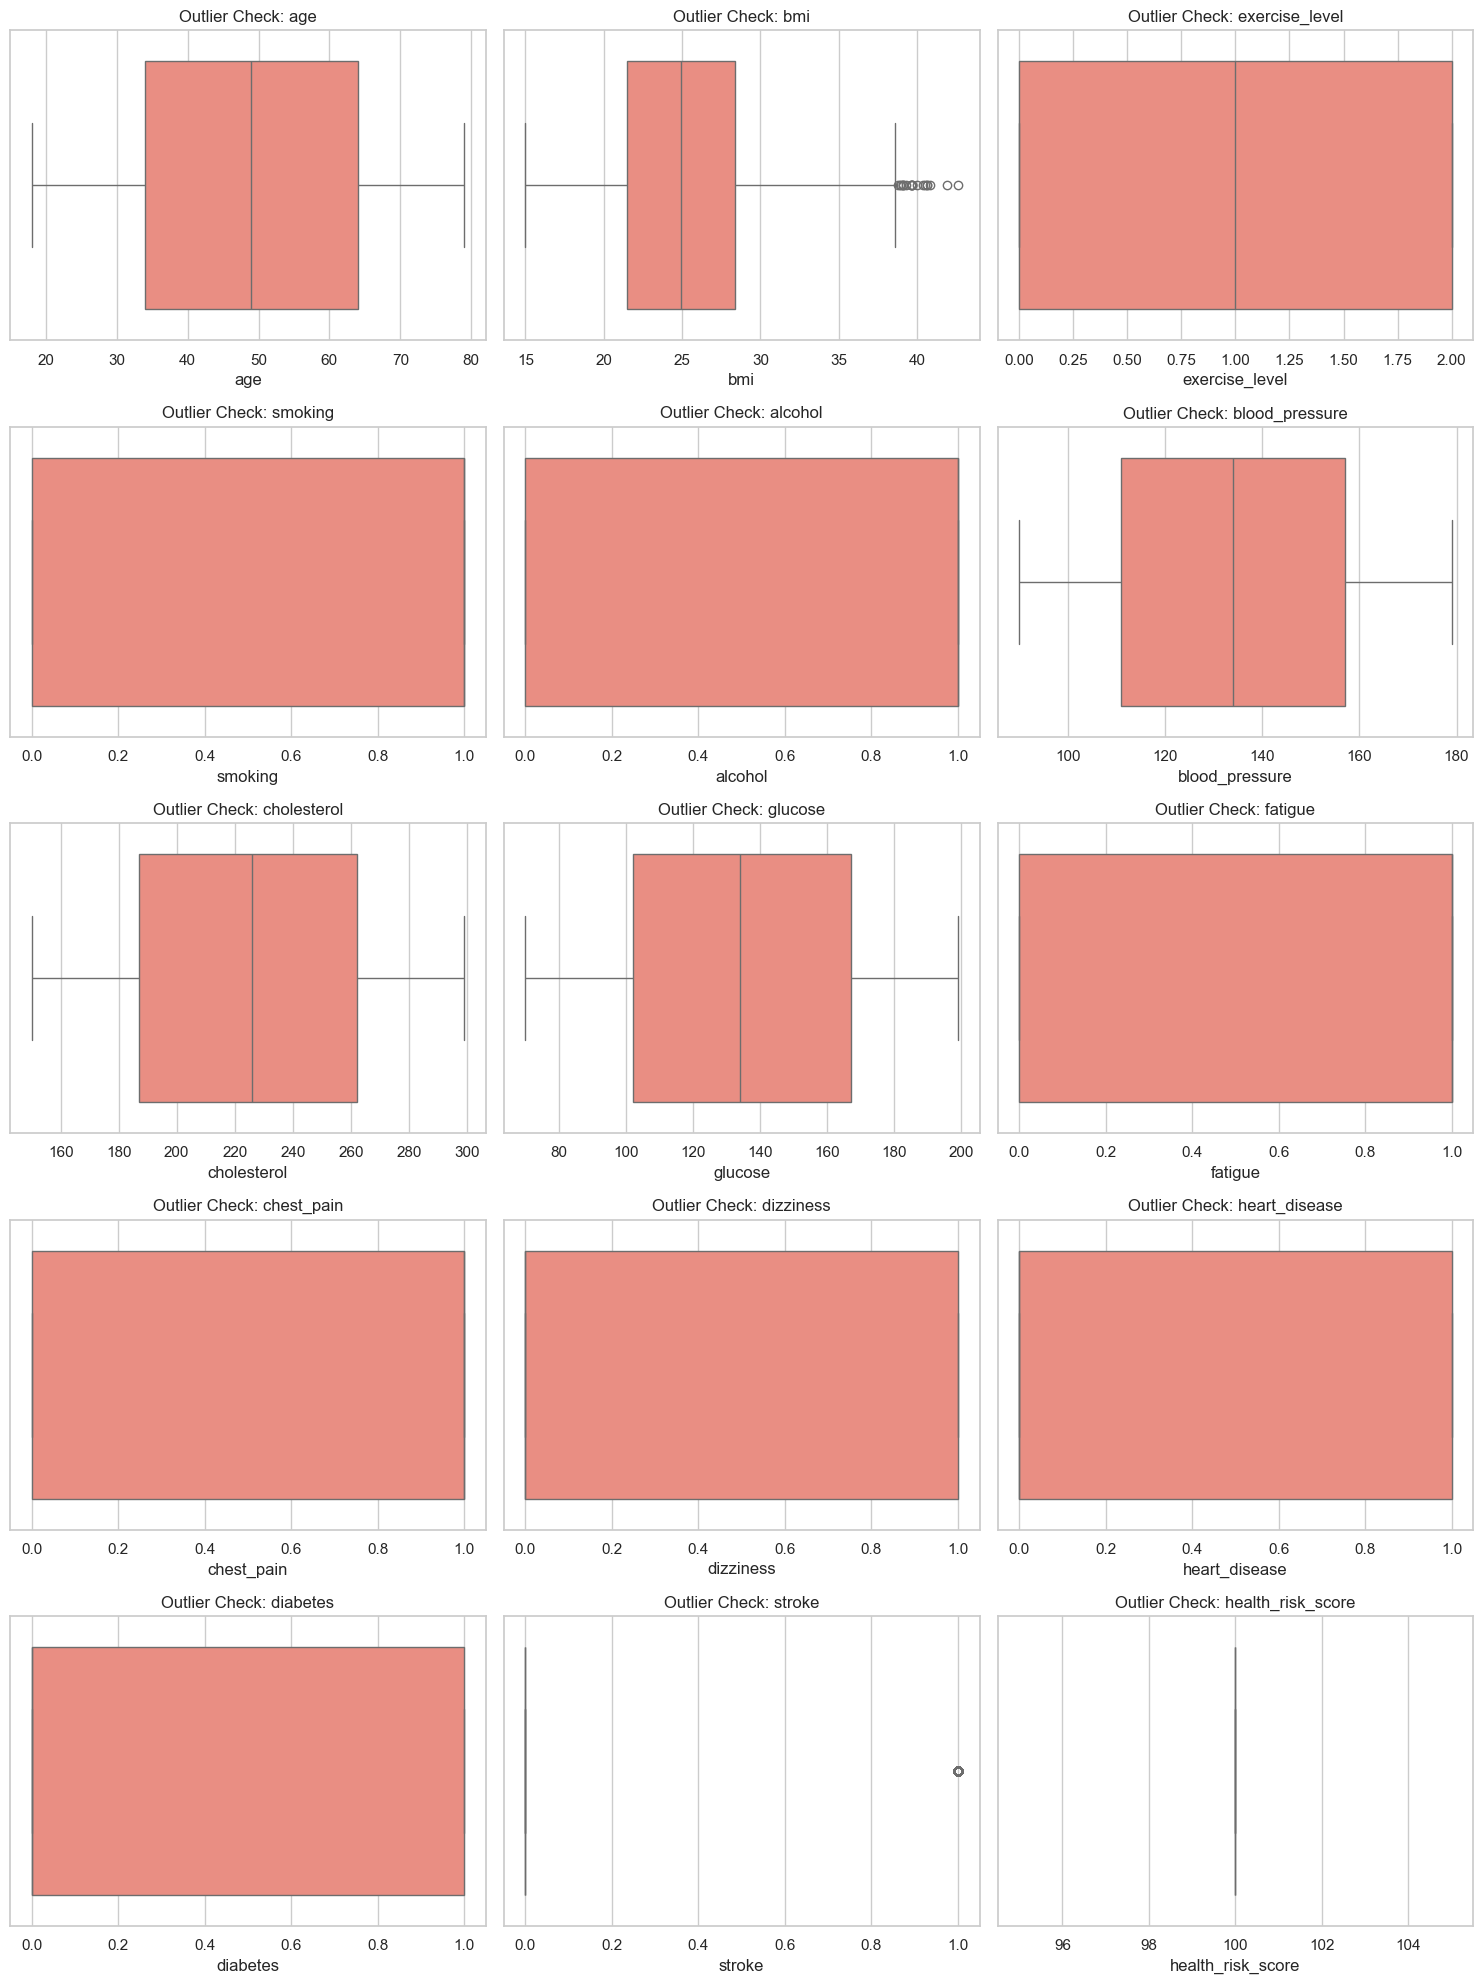

In [12]:
import math

# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_plots = len(numeric_cols)

# Dynamically calculate rows needed for 3 columns
cols = 3
rows = math.ceil(num_plots / cols)

plt.figure(figsize=(15, rows * 4)) # Adjust height based on rows

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1) # Use dynamic rows and cols
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Outlier Check: {col}')

plt.tight_layout()
plt.show()

In [14]:
import sys
import os

# 1. Add the parent directory to the system path so Python can find 'src'
sys.path.append(os.path.abspath('..')) 

# 2. Import your config and the function from your preprocessing.py file
# (Assuming your file is named preprocessing.py inside the src folder)
import config
from src.preprocessing import full_preprocessing_and_save

# 3. Call the function
print("⚙️ Starting Full Preprocessing...")
X_train, X_test, y_train, y_test = full_preprocessing_and_save(
    file_path='../' + config.DATA_PATH, 
    output_dir='../data/processed/'
)

print(f"✅ Preprocessing Complete.")
print(f"Train features shape: {X_train.shape}")

⚙️ Starting Full Preprocessing...
✅ Advanced processing complete! 13 features ready.
📁 Processed files saved in: ../data/processed/
✅ Preprocessing Complete.
Train features shape: (4000, 13)
